In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display

DATA = Path("../data")
DATA.mkdir(exist_ok=True)

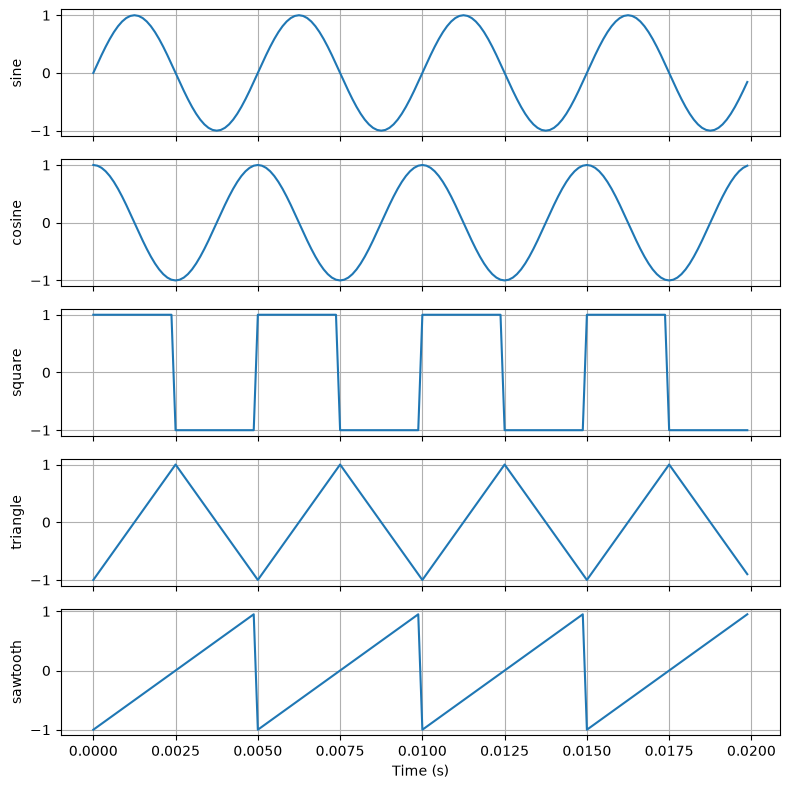

In [2]:
from audiolab.generator import generate_signal

fs, f, amp, dur = 8000, 200, 1.0, 0.02   # 200 Hz for 20 ms

fig, axs = plt.subplots(5, 1, figsize=(8, 8), sharex=True)
for ax, waveform in zip(axs, ["sine", "cosine", "square", "triangle", "sawtooth"]):
    t, y = generate_signal(waveform, f, amp, fs, dur)
    ax.plot(t, y)
    ax.set_ylabel(waveform)
    ax.grid(True)

axs[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

In [3]:
fs, f, amp, dur = 44100, 440, 0.5, 2.0    # A4 (440 Hz), 2 s, amplitude 0.5
t, y = generate_signal("sine", f, amp, fs, dur)

Audio(y, rate=fs)

In [4]:
from audiolab.audio_io import save_audio, load_audio

save_audio(DATA / "sine_440.wav", y, fs)       # save
y2, fs2 = load_audio(DATA / "sine_440.wav")    # read it back

print("fs:", fs2, "| duration:", len(y2) / fs2, "s")
print("Matches the original?", np.allclose(y, y2, atol=1e-4))

fs: 44100 | duration: 2.0 s
Matches the original? True


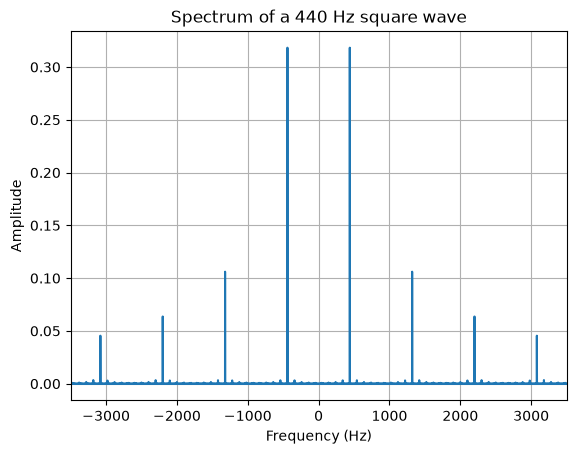

Peak at: 440.0 Hz | value: 0.3183099131066679


In [5]:
from audiolab.analysis import compute_spectrum

fs = 44100
t, y = generate_signal("square", 440, 0.5, fs, 1.0)     # 1 second
f, P = compute_spectrum(y, fs)

plt.plot(f, P)
plt.xlim(-3500, 3500)                                # zoom around 0 Hz
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Spectrum of a 440 Hz square wave")
plt.grid(True)
plt.show()

pos = f > 0
print("Peak at:", f[pos][np.argmax(P[pos])], "Hz | value:", P.max())

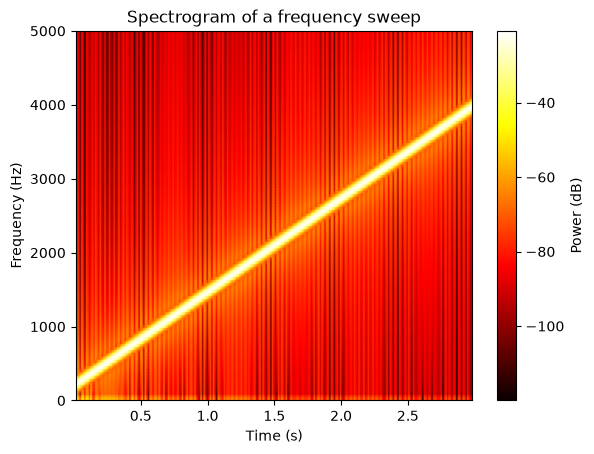

In [6]:
from scipy import signal
from audiolab.analysis import compute_spectrogram

fs = 44100
t = np.arange(0, 3.0, 1/fs)
y = signal.chirp(t, f0=200, t1=3.0, f1=4000)     # sweep from 200 to 4000 Hz in 3 s

f, tt, S_dB = compute_spectrogram(y, fs)

plt.pcolormesh(tt, f, S_dB, cmap="hot", shading="gouraud")
plt.ylim(0, 5000)
plt.colorbar(label="Power (dB)")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Spectrogram of a frequency sweep")
plt.show()

In [7]:
from audiolab.processing import change_speed, time_stretch

fs = 44100
t, y = generate_signal("sine", 440, 0.5, fs, 2.0)

def peak(y, fs):
    f, P = compute_spectrum(y, fs)
    pos = f > 0
    return f[pos][np.argmax(P[pos])]

y_a, fs_a = change_speed(y, fs, 2)
y_b, fs_b = time_stretch(y, fs, 2)

print(f"Original:      {len(y)/fs:.2f} s | peak {peak(y, fs):.0f} Hz")
print(f"Speed x2:      {len(y_a)/fs_a:.2f} s | peak {peak(y_a, fs_a):.0f} Hz")
print(f"Time-stretch:  {len(y_b)/fs_b:.2f} s | peak {peak(y_b, fs_b):.0f} Hz")

C:\proyectos\audiolab\.venv\Lib\site-packages\librosa\effects.py:448: FutureWarning: The `hop_length` parameter is deprecated as of 1.0 and will be removed in 1.1. It is unused in the current implementation.
  stft_stretch = core.phase_vocoder(
C:\proyectos\audiolab\.venv\Lib\site-packages\librosa\effects.py:448: FutureWarning: The `n_fft` parameter is deprecated as of 1.0 and will be removed in 1.1. It is unused in the current implementation.
  stft_stretch = core.phase_vocoder(


Original:      2.00 s | peak 440 Hz
Speed x2:      1.00 s | peak 880 Hz
Time-stretch:  1.00 s | peak 440 Hz


In [8]:
display(Audio(y_a, rate=fs_a))   # speed change: higher pitch
display(Audio(y_b, rate=fs_b))   # time-stretch: same pitch

fs: 22050 Hz | samples: 117601 | duration: 5.33 s | range: [-0.68, 0.63]


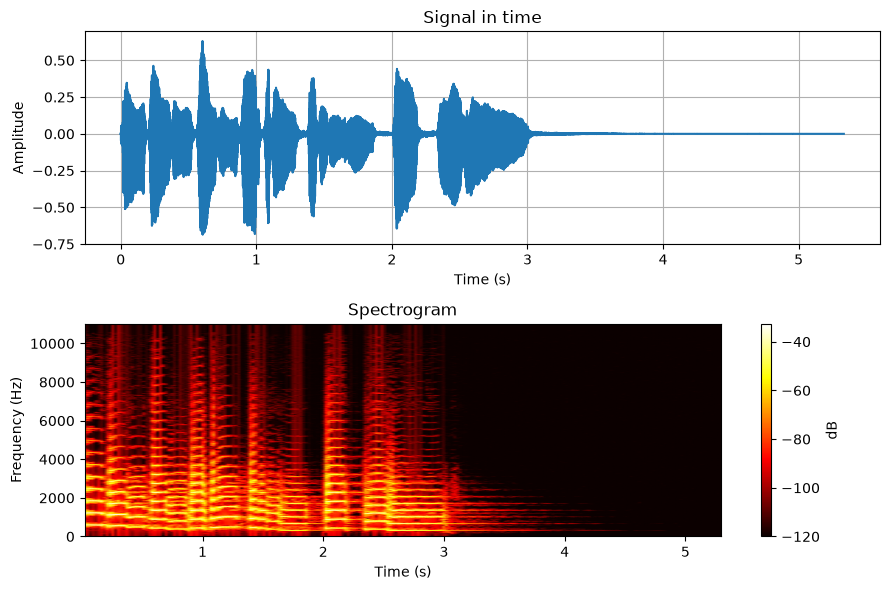

In [9]:
import librosa

y, fs = load_audio(librosa.ex("trumpet"))     # replace with the path to any audio file of yours
print(f"fs: {fs} Hz | samples: {len(y)} | duration: {len(y)/fs:.2f} s | range: [{y.min():.2f}, {y.max():.2f}]")

t = np.arange(len(y)) / fs
f, tt, S_dB = compute_spectrogram(y, fs)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6))
ax1.plot(t, y)
ax1.set_title("Signal in time")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Amplitude")
ax1.grid(True)

im = ax2.pcolormesh(tt, f, S_dB, cmap="hot", shading="gouraud")
ax2.set_title("Spectrogram")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Frequency (Hz)")
fig.colorbar(im, ax=ax2, label="dB")

plt.tight_layout()
plt.show()

Audio(y, rate=fs)

In [ ]:
from audiolab.audio_io import record_audio

print("Recording 3 seconds... speak now")
y, fs = record_audio(3)
print("Recording finished")

print(f"fs: {fs} Hz | samples: {len(y)} | peak amplitude: {np.abs(y).max():.3f}")

t = np.arange(len(y)) / fs
plt.plot(t, y)
plt.title("Recording")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

save_audio(DATA / "recording.wav", y, fs)
Audio(y, rate=fs)

X: (800, 16000) | y: (800,)
sine -> 200 signals
square -> 200 signals
triangle -> 200 signals
sawtooth -> 200 signals


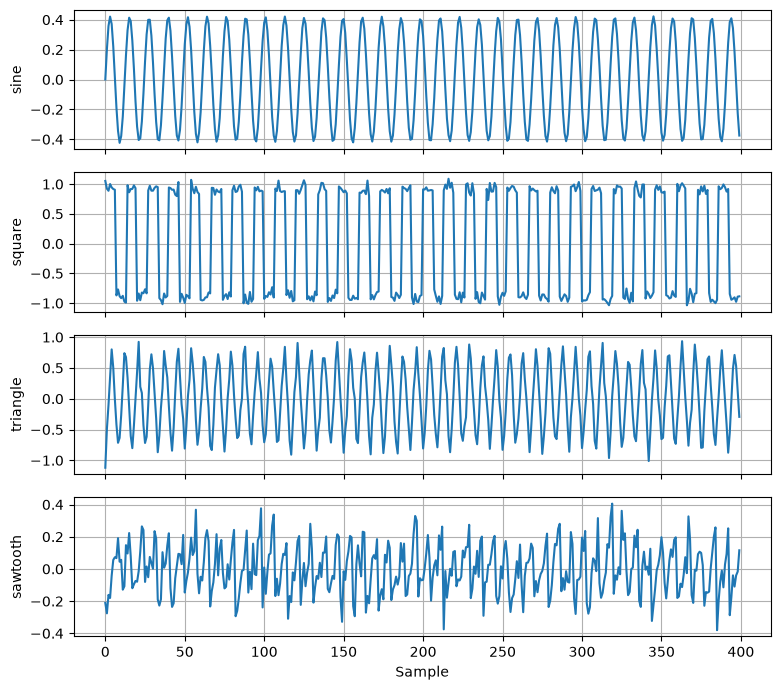

In [10]:
from audiolab.dataset import generate_dataset, WAVEFORMS

fs = 16000
X, y = generate_dataset(n_per_class=200, fs=fs)

print("X:", X.shape, "| y:", y.shape)
for waveform in WAVEFORMS:
    print(waveform, "->", np.sum(y == waveform), "signals")

fig, axs = plt.subplots(4, 1, figsize=(8, 7), sharex=True)
for ax, waveform in zip(axs, WAVEFORMS):
    example = X[y == waveform][0]
    ax.plot(example[:400])
    ax.set_ylabel(waveform)
    ax.grid(True)
axs[-1].set_xlabel("Sample")
plt.tight_layout()
plt.show()

In [11]:
from audiolab.features import extract_mfcc_features_dataset

X_mfcc = extract_mfcc_features_dataset(X, fs)

print("Signals: ", X.shape)
print("Features:", X_mfcc.shape)
print("First 5 features of the first signal:", np.round(X_mfcc[0][:5], 1))

Signals:  (800, 16000)
Features: (800, 40)
First 5 features of the first signal: [-289.6    9.5  -25.2  -18.    13.7]


Train: (640, 40) | Test: (160, 40)


Train accuracy: 1.0
Test accuracy:  0.89375


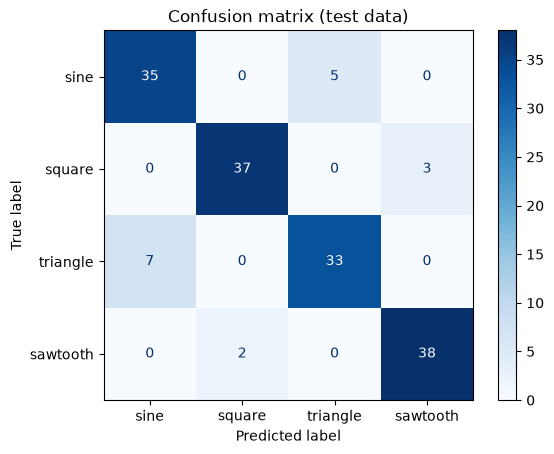

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay

X_train, X_test, y_train, y_test = train_test_split(
    X_mfcc, y, test_size=0.2, stratify=y, random_state=0
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

model = RandomForestClassifier(n_estimators=200, random_state=0)
model.fit(X_train, y_train)

print("Train accuracy:", model.score(X_train, y_train))
print("Test accuracy: ", model.score(X_test, y_test))

y_pred = model.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=WAVEFORMS, cmap="Blues")
plt.title("Confusion matrix (test data)")
plt.show()

In [13]:
from audiolab.features import extract_harmonic_features_dataset

X_harm = extract_harmonic_features_dataset(X, fs)
print("Harmonic features:", X_harm.shape)

def evaluate(D, name):
    D_train, D_test, y_train, y_test = train_test_split(
        D, y, test_size=0.2, stratify=y, random_state=0
    )
    model = RandomForestClassifier(n_estimators=200, random_state=0).fit(D_train, y_train)
    print(f"{name:10s} train: {model.score(D_train, y_train):.3f} | test: {model.score(D_test, y_test):.3f}")

evaluate(X_mfcc, "MFCC")
evaluate(X_harm, "Harmonics")
evaluate(np.hstack([X_mfcc, X_harm]), "Both")

Harmonic features: (800, 8)


MFCC       train: 1.000 | test: 0.894


Harmonics  train: 1.000 | test: 1.000


Both       train: 1.000 | test: 1.000


In [14]:
np.set_printoptions(precision=2, suppress=True)
for waveform in WAVEFORMS:
    print(f"{waveform:9s}", X_harm[y == waveform][:, 1:].mean(axis=0))

sine      [0. 0. 0. 0. 0. 0. 0.]
square    [0.   0.33 0.   0.14 0.   0.06 0.  ]
triangle  [0.   0.11 0.   0.03 0.   0.01 0.  ]
sawtooth  [0.5  0.34 0.25 0.16 0.11 0.07 0.05]
